# 🚗 Task 1: Offline Traffic-State Reconstruction
### 2026 IEEE Big Data Cup — Traffic Flow Bench

This notebook implements the complete end-to-end pipeline for **Task 1: Traffic State Estimation**:
1. **Understanding & EDA**: Inspect corridor networks, detector layout, and masking regimes ($R_1, R_2, R_3$).
2. **Feature Engineering**: Build high-resolution spatio-temporal profiles (Weekday $\times$ 5-minute Time-of-Day slot).
3. **Model Construction**: Link-specific historical baseline with fallback handling and non-negativity clipping.
4. **Local Evaluation**: Evaluate on the `train` split against ground truth using the official competition NRMSE metric.
5. **Inference & Export**: Generate predictions for the `validation` split targets and export to CSV ready for submission.

## 1. Setup & Environment
Import libraries and define directories. Ensure `.venv` is activated.

In [9]:
import os
import sys
import json
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Set plotting aesthetic
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Define workspace paths
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
RELEASE_ROOT = PROJECT_ROOT / 'kaggle_public'
DATASETS_DIR = PROJECT_ROOT / 'datasets'
DATASETS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Release root: {RELEASE_ROOT} (exists: {RELEASE_ROOT.exists()})")
print(f"Datasets dir: {DATASETS_DIR}")

Project root: /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench
Release root: /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench/kaggle_public (exists: True)
Datasets dir: /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench/datasets


## 2. Competition Contract & Corridor Metadata
Inspect the 10 corridors and Task 1 scoring definitions from `config/`.

In [10]:
with open(RELEASE_ROOT / 'config' / 'corridors.json') as f:
    corridors_cfg = json.load(f)

with open(RELEASE_ROOT / 'config' / 'competition_contract.json') as f:
    contract_cfg = json.load(f)

ALL_PANELS = [p['corridor_id'] for p in corridors_cfg['panels']]
task1_cfg = contract_cfg['tasks']['state']

print(f"Directional Panels ({len(ALL_PANELS)} total):\n  {ALL_PANELS}")
print("\nTask 1 Contract Specifications:")
print(f"  - Masking Regimes: {task1_cfg['masking_regimes']}")
print(f"  - Speed Weight: {task1_cfg['speed_weight']} (Normalizer: {task1_cfg['speed_normalizer']} km/h)")
print(f"  - Flow Weight: {task1_cfg['flow_weight']} (Normalizer: {task1_cfg['flow_normalizer']} vph/lane)")

Directional Panels (10 total):
  ['D7_I10_E', 'D7_I10_W', 'D7_I210_E', 'D7_I210_W', 'D7_I405_N', 'D7_I405_S', 'D12_I5_N', 'D12_I5_S', 'D12_I405_N', 'D12_I405_S']

Task 1 Contract Specifications:
  - Masking Regimes: {'R1': 0.2, 'R2': 0.3, 'R3': 0.5}
  - Speed Weight: 0.54 (Normalizer: 25.0 km/h)
  - Flow Weight: 0.46 (Normalizer: 600.0 vph/lane)


## 3. Exploratory Data Analysis (EDA)
Let's explore a sample panel: `D12_I5_N`.
We examine:
- Network topology (`links.csv`) and sensor capacities (`fd_parameters.csv`).
- Unmasked observations vs masked observations.
- Diurnal profiles and detector dropout patterns.

In [11]:
sample_panel = 'D12_I5_N'
network_dir = RELEASE_ROOT / 'corridors' / sample_panel / 'network'

links_df = pd.read_csv(network_dir / 'links.csv')
fd_df = pd.read_csv(network_dir / 'fd_parameters.csv')

print(f"--- {sample_panel} Network Links (First 5 links) ---")
display(links_df.head())

print(f"\n--- {sample_panel} Fundamental Diagram Parameters ---")
display(fd_df.head())

--- D12_I5_N Network Links (First 5 links) ---


,link_id,length_km,lanes,free_speed_kmh,capacity_vph
0,L5N-186,1.454,4.0,114.7,8150.4
1,L5N-182,0.549,4.0,116.7,8006.4
2,L5N-177,0.025,4.0,117.5,8419.2
3,L5N-176,0.368,4.0,117.5,8419.2
4,L5N-017,0.084,4.0,117.5,8419.2



--- D12_I5_N Fundamental Diagram Parameters ---


,link_id,length_km,lanes,free_speed_kmh,capacity_vph,critical_density,k_jam
0,L5N-186,1.454,4.0,114.7,8150.4,71.058413,400.0
1,L5N-182,0.549,4.0,116.7,8006.4,68.606684,400.0
2,L5N-177,0.025,4.0,117.5,8419.2,71.652766,400.0
3,L5N-176,0.368,4.0,117.5,8419.2,71.652766,400.0
4,L5N-017,0.084,4.0,117.5,8419.2,71.652766,400.0


### Comparing Unmasked Ground Truth vs Masked Observations
Let's load the first partition from the `train` split in both unmasked and masked forms.

In [12]:
sample_unmasked_file = sorted((RELEASE_ROOT / 'corridors' / sample_panel / 'train' / 'mainline_states').glob('**/*.parquet'))[0]
sample_masked_file = sorted((RELEASE_ROOT / 'corridors' / sample_panel / 'train' / 'mainline_states_masked').glob('**/*.parquet'))[0]

df_unmasked = pd.read_parquet(sample_unmasked_file)
df_masked = pd.read_parquet(sample_masked_file)

print(f"Unmasked sample: {sample_unmasked_file.name} -> {len(df_unmasked):,} rows")
print(f"Masked sample:   {sample_masked_file.name} -> {len(df_masked):,} rows")
print(f"Null speed in unmasked: {df_unmasked['speed_kmh'].isna().sum()}")
print(f"Null speed in masked (Targets to impute!): {df_masked['speed_kmh'].isna().sum()} ({df_masked['speed_kmh'].isna().mean():.1%})")

Unmasked sample: synthetic_mainline_2030_06_01.parquet -> 74,304 rows
Masked sample:   synthetic_mainline_2030_06_04.parquet -> 74,304 rows
Null speed in unmasked: 12222
Null speed in masked (Targets to impute!): 23054 (31.0%)


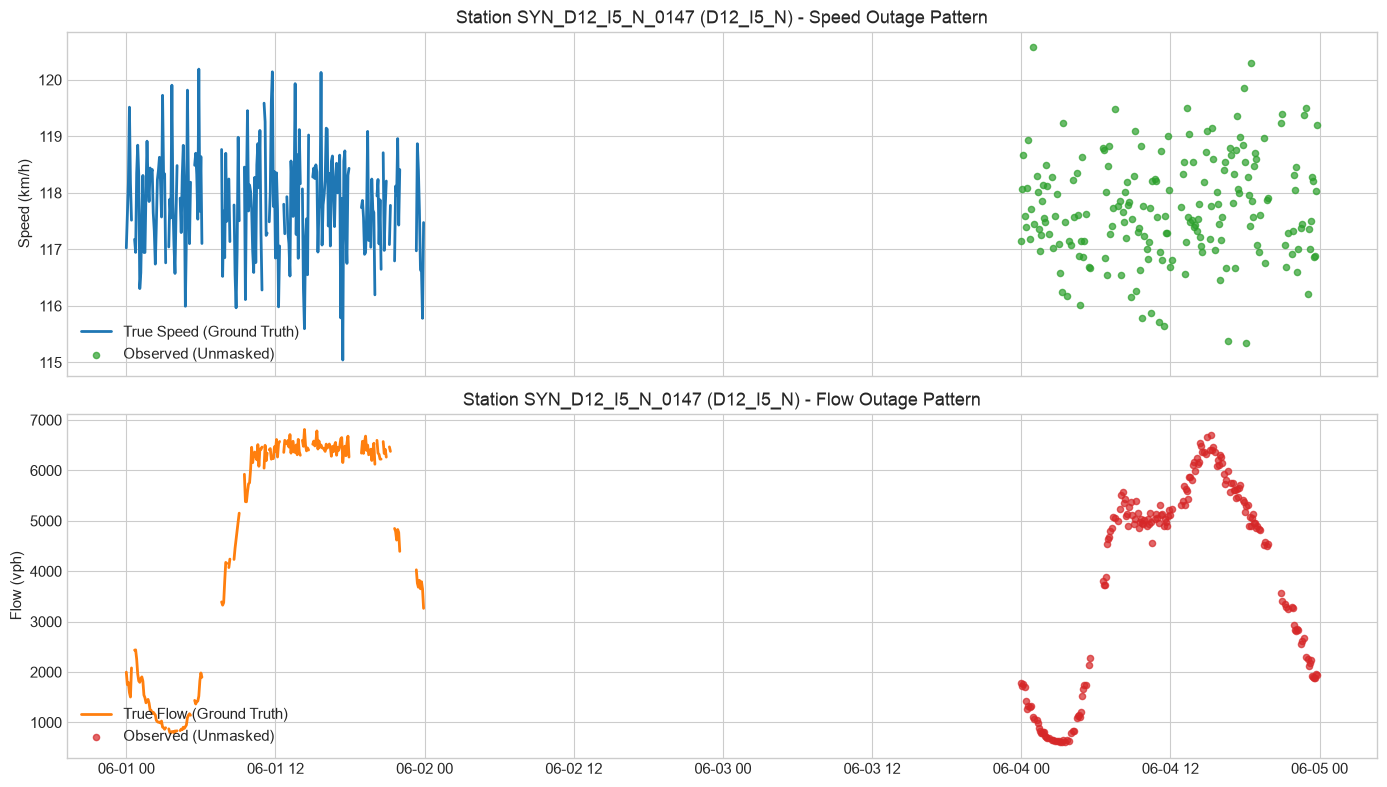

In [13]:
# Plot sample time-series for a single sensor station
sample_station = df_unmasked['station_id'].iloc[0]
st_unmasked = df_unmasked[df_unmasked['station_id'] == sample_station].sort_values('timestamp')
st_masked = df_masked[df_masked['station_id'] == sample_station].sort_values('timestamp')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(pd.to_datetime(st_unmasked['timestamp']), st_unmasked['speed_kmh'], label='True Speed (Ground Truth)', color='#1f77b4', lw=2)
ax1.scatter(pd.to_datetime(st_masked['timestamp']), st_masked['speed_kmh'], label='Observed (Unmasked)', color='#2ca02c', s=20, alpha=0.7)
ax1.set_ylabel('Speed (km/h)')
ax1.set_title(f'Station {sample_station} ({sample_panel}) - Speed Outage Pattern')
ax1.legend(loc='lower left')

ax2.plot(pd.to_datetime(st_unmasked['timestamp']), st_unmasked['flow_vph'], label='True Flow (Ground Truth)', color='#ff7f0e', lw=2)
ax2.scatter(pd.to_datetime(st_masked['timestamp']), st_masked['flow_vph'], label='Observed (Unmasked)', color='#d62728', s=20, alpha=0.7)
ax2.set_ylabel('Flow (vph)')
ax2.set_title(f'Station {sample_station} ({sample_panel}) - Flow Outage Pattern')
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

## 4. Spatio-Temporal Profile Model Architecture
For each link $l$ and each 5-minute time slot $t \in [0, 287]$ on day of week $w \in [0, 6]$:
- Index: $\text{slot} = w \times 288 + t$ ($2,016$ discrete slots per week).
- We aggregate observations across the 273 days of `train` observations.
- Any missing slots fall back to the link overall mean.

In [14]:
SLOTS_PER_WEEK = 7 * 288  # 2016 slots (5-minute resolution)

def slot_values(frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    """Extract weekday (0-6) and time-of-day slot (0-287) from UTC timestamp."""
    ts = pd.to_datetime(frame['timestamp'], utc=True)
    weekday = ts.dt.weekday.to_numpy(dtype=np.int16)
    tod = (ts.dt.hour * 12 + ts.dt.minute // 5).to_numpy(dtype=np.int16)
    return weekday, tod

def build_panel_profile(panel: str, release: Path):
    """Build link-level historical mean profiles for speed and flow from train split."""
    panel_dir = release / 'corridors' / panel
    links_df = pd.read_csv(panel_dir / 'network' / 'links.csv')
    link_ids = sorted(links_df['link_id'].astype(str).unique())
    link_index = {lid: i for i, lid in enumerate(link_ids)}
    n_links = len(link_ids)
    
    speed_sum = np.zeros((n_links, SLOTS_PER_WEEK), dtype=np.float64)
    speed_count = np.zeros((n_links, SLOTS_PER_WEEK), dtype=np.int32)
    flow_sum = np.zeros((n_links, SLOTS_PER_WEEK), dtype=np.float64)
    flow_count = np.zeros((n_links, SLOTS_PER_WEEK), dtype=np.int32)
    
    train_files = sorted((panel_dir / 'train' / 'mainline_states').glob('**/*.parquet'))
    
    for path in tqdm(train_files, desc=f"Building profile for {panel}", leave=False):
        frame = pd.read_parquet(path, columns=['timestamp', 'link_id', 'speed_kmh', 'flow_vph', 'is_score_eligible'])
        frame = frame[frame['is_score_eligible'].astype(bool)]
        if frame.empty:
            continue
            
        weekday, tod = slot_values(frame)
        slot = weekday * 288 + tod
        li = frame['link_id'].astype(str).map(link_index).fillna(-1).to_numpy(dtype=np.int64)
        known = li >= 0
        
        s_valid = known & frame['speed_kmh'].notna().to_numpy()
        if np.any(s_valid):
            np.add.at(speed_sum, (li[s_valid], slot[s_valid]), frame['speed_kmh'].to_numpy(dtype=np.float64)[s_valid])
            np.add.at(speed_count, (li[s_valid], slot[s_valid]), 1)
            
        f_valid = known & frame['flow_vph'].notna().to_numpy()
        if np.any(f_valid):
            np.add.at(flow_sum, (li[f_valid], slot[f_valid]), frame['flow_vph'].to_numpy(dtype=np.float64)[f_valid])
            np.add.at(flow_count, (li[f_valid], slot[f_valid]), 1)
            
    with np.errstate(divide='ignore', invalid='ignore'):
        speed_mean = np.where(speed_count > 0, speed_sum / np.maximum(speed_count, 1), np.nan)
        flow_mean = np.where(flow_count > 0, flow_sum / np.maximum(flow_count, 1), np.nan)
        
    link_speed_fallback = np.nanmean(speed_mean, axis=1)
    link_flow_fallback = np.nanmean(flow_mean, axis=1)
    
    speed_profile = np.where(speed_count > 0, speed_mean, link_speed_fallback[:, None])
    flow_profile = np.where(flow_count > 0, flow_mean, link_flow_fallback[:, None])
    
    return {
        'link_index': link_index,
        'speed_profile': speed_profile,
        'flow_profile': flow_profile
    }

## 5. Local Scoring & Evaluation on `train`
Compute NRMSE and score per regime:
$$S_{\text{regime}} = \exp\left( - (0.54 \times \frac{\text{RMSE}_{\text{speed}}}{25.0} + 0.46 \times \frac{\text{RMSE}_{\text{flow\_lane}}}{600.0}) \right)$$

In [15]:
def evaluate_panel_local(panel: str, release: Path, profile_data: dict, sample_days: int = 15):
    """Local scoring on a subset of train days to verify reconstruction accuracy."""
    panel_dir = release / 'corridors' / panel
    links_df = pd.read_csv(panel_dir / 'network' / 'links.csv')
    lanes_map = dict(zip(links_df['link_id'].astype(str), links_df['lanes']))
    
    truth_paths = sorted((panel_dir / 'train' / 'mainline_states').glob('**/*.parquet'))
    truth_by_name = {p.name: p for p in truth_paths}
    
    link_index = profile_data['link_index']
    speed_prof = profile_data['speed_profile']
    flow_prof = profile_data['flow_profile']
    
    regime_results = {}
    
    for regime in ['R1', 'R2', 'R3']:
        masked_files = sorted((panel_dir / 'train' / 'mainline_states_masked' / f'mask_regime={regime}').glob('*.parquet'))[:sample_days]
        if not masked_files:
            continue
            
        sq_err_speed, sq_err_flow, total_count = 0.0, 0.0, 0
        
        for mf in masked_files:
            unmasked_file = truth_by_name.get(mf.name)
            if not unmasked_file:
                continue
                
            m_df = pd.read_parquet(mf, columns=['timestamp', 'station_id', 'link_id', 'speed_kmh', 'flow_vph'])
            u_df = pd.read_parquet(unmasked_file, columns=['timestamp', 'station_id', 'link_id', 'speed_kmh', 'flow_vph', 'is_score_eligible'])
            
            target_mask = m_df['speed_kmh'].isna() & u_df['is_score_eligible'].astype(bool)
            if not np.any(target_mask):
                continue
                
            t_df = u_df[target_mask].copy()
            weekday, tod = slot_values(t_df)
            slot = weekday * 288 + tod
            li = t_df['link_id'].astype(str).map(link_index).fillna(0).to_numpy(dtype=np.int64)
            
            pred_speed = np.maximum(speed_prof[li, slot], 0.0)
            pred_flow = np.maximum(flow_prof[li, slot], 0.0)
            
            true_speed = t_df['speed_kmh'].to_numpy(dtype=np.float64)
            true_flow = t_df['flow_vph'].to_numpy(dtype=np.float64)
            lanes = t_df['link_id'].astype(str).map(lanes_map).fillna(1.0).to_numpy(dtype=np.float64)
            
            sq_err_speed += np.sum((pred_speed - true_speed) ** 2)
            sq_err_flow += np.sum(((pred_flow - true_flow) / lanes) ** 2)
            total_count += len(t_df)
            
        if total_count > 0:
            rmse_s = np.sqrt(sq_err_speed / total_count)
            rmse_q = np.sqrt(sq_err_flow / total_count)
            norm_s = rmse_s / 25.0
            norm_q = rmse_q / 600.0
            score = np.exp(-(0.54 * norm_s + 0.46 * norm_q))
            regime_results[regime] = {
                'Speed RMSE (km/h)': rmse_s,
                'Flow RMSE (vph/lane)': rmse_q,
                'Score': score
            }
            
    res_df = pd.DataFrame(regime_results).T
    print(f"\n=== Local Validation Results for {panel} ===")
    display(res_df.round(4))
    if not res_df.empty and 'Score' in res_df.columns:
        print(f"Overall Panel S_state: {res_df['Score'].mean():.4f}")
    return res_df

## 6. Inference on `validation` Split & Export to CSV
We generate predictions for the official target cells matching `sample_submission_state.csv`.

> **Note**: Set `SELECTED_PANELS = ['D12_I5_N']` for fast demonstration (~30s), or `SELECTED_PANELS = ALL_PANELS` for all 10 corridors.

In [16]:
SELECTED_PANELS = ['D12_I5_N']  # Change to ALL_PANELS for the full 10 corridors
SPLIT = 'validation'

all_predictions = []

for panel in SELECTED_PANELS:
    print(f"\n>>> Processing Corridor: {panel}")
    profile = build_panel_profile(panel, RELEASE_ROOT)
    
    # Run local validation check
    evaluate_panel_local(panel, RELEASE_ROOT, profile, sample_days=10)
    
    # Read official template keys for exact target alignment
    template_path = RELEASE_ROOT / 'task1' / panel / SPLIT / 'sample_submission_state.csv'
    template_df = pd.read_csv(template_path, dtype=str)
    template_keys = set(zip(template_df['timestamp'], template_df['station_id'], template_df['link_id']))
    print(f"Target template rows to predict: {len(template_df):,}")
    
    link_index = profile['link_index']
    speed_prof = profile['speed_profile']
    flow_prof = profile['flow_profile']
    
    panel_dir = RELEASE_ROOT / 'corridors' / panel
    masked_paths = sorted((panel_dir / SPLIT / 'mainline_states_masked').glob('**/*.parquet'))
    
    panel_rows = []
    for path in tqdm(masked_paths, desc=f"Inference {panel}", leave=False):
        frame = pd.read_parquet(path, columns=['timestamp', 'station_id', 'link_id', 'mask_regime'])
        frame['station_id'] = frame['station_id'].astype(str)
        frame['link_id'] = frame['link_id'].astype(str)
        frame['timestamp'] = frame['timestamp'].astype(str)
        
        is_target = np.fromiter(
            (k in template_keys for k in zip(frame['timestamp'], frame['station_id'], frame['link_id'])),
            dtype=bool,
            count=len(frame)
        )
        
        if not np.any(is_target):
            continue
            
        target_df = frame[is_target].copy()
        weekday, tod = slot_values(target_df)
        slot = weekday * 288 + tod
        li = target_df['link_id'].map(link_index).fillna(0).to_numpy(dtype=np.int64)
        
        target_df['panel'] = panel
        target_df['speed_kmh'] = np.maximum(speed_prof[li, slot], 0.0)
        target_df['flow_vph'] = np.maximum(flow_prof[li, slot], 0.0)
        
        panel_rows.append(target_df[['panel', 'timestamp', 'station_id', 'link_id', 'mask_regime', 'speed_kmh', 'flow_vph']])
        
    panel_pred_df = pd.concat(panel_rows, ignore_index=True)
    print(f"Generated {len(panel_pred_df):,} predictions for {panel}")
    all_predictions.append(panel_pred_df)

submission_task1_df = pd.concat(all_predictions, ignore_index=True)
print(f"\nTotal Task 1 predictions generated: {len(submission_task1_df):,}")


>>> Processing Corridor: D12_I5_N


Building profile for D12_I5_N:   0%|          | 0/273 [00:00<?, ?it/s]


=== Local Validation Results for D12_I5_N ===


,Speed RMSE (km/h),Flow RMSE (vph/lane),Score
R1,11.5473,82.0343,0.7318
R2,13.8510,127.6999,0.6723
R3,14.1030,111.8980,0.6768


Overall Panel S_state: 0.6936
Target template rows to predict: 588,468


Inference D12_I5_N:   0%|          | 0/31 [00:00<?, ?it/s]

Generated 588,468 predictions for D12_I5_N

Total Task 1 predictions generated: 588,468


## 7. Integrity Checks & Export to CSV
Ensure the data has no missing or negative values, and export to `datasets/task1_state_submission.csv`.

In [17]:
# Integrity Checks
assert submission_task1_df['speed_kmh'].isna().sum() == 0, "Found NaN in speed_kmh"
assert submission_task1_df['flow_vph'].isna().sum() == 0, "Found NaN in flow_vph"
assert (submission_task1_df['speed_kmh'] < 0).sum() == 0, "Found negative speed"
assert (submission_task1_df['flow_vph'] < 0).sum() == 0, "Found negative flow"

print(" All integrity assertions passed!")
print("\n--- Prediction Summary Statistics ---")
display(submission_task1_df[['speed_kmh', 'flow_vph']].describe().round(2))

# Export to CSV in datasets/
output_csv_path = DATASETS_DIR / 'task1_state_submission.csv'
submission_task1_df.to_csv(output_csv_path, index=False)

file_size_mb = output_csv_path.stat().st_size / (1024 * 1024)
print(f"\n Exported Task 1 CSV: {output_csv_path}")
print(f"   Size: {file_size_mb:.2f} MB | Rows: {len(submission_task1_df):,}")

 All integrity assertions passed!

--- Prediction Summary Statistics ---


,speed_kmh,flow_vph
count,588468.00,588468.00
mean,113.00,4061.16
std,13.09,1999.71
min,21.23,580.06
25%,115.55,2105.48
50%,117.19,4878.11
75%,117.95,5771.53
max,120.75,8319.66



 Exported Task 1 CSV: /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench/datasets/task1_state_submission.csv
   Size: 53.83 MB | Rows: 588,468


## 8. Summary & Next Steps
- **Task 1 Submission Ready**: Saved to `datasets/task1_state_submission.csv`.
- **Next Step**: Once Task 2 (`queue`) and Task 4 (`odme`) predictions are generated, merge them using:
```bash
python trafficflowbench-public/src/merge_submissions.py \
  --state datasets/task1_state_submission.csv \
  --queue queue_submission.csv \
  --odme  task4_submission.csv \
  --key   kaggle_public/submission_key.csv \
  --output submission.csv
```